# Habituation/Dishabituation Example Recordings

This notebook plots the first 30 seconds after each bout introduction and overlays `Investigation` epochs on top of the DA trace.

It is set up so you can:
- load either NAc or mPFC recordings,
- view multiple subjects in the same figure,
- compare several bouts side by side,
- keep the investigation overlay style consistent with your existing plotting functions.

In [2]:
import os
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().resolve().name == 'Hab_Dishab' else Path.cwd().resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from experiment_class import Experiment

In [3]:
# Update these paths if your data live somewhere else.
NAC_EXPERIMENT_PATH = r"C:\Users\alber\OneDrive\Desktop\PC_Lab\Photometry\Pilot_2\Combined_Cohorts\Hab_Dishab\All\nac"
NAC_CSV_PATH =  r"C:\Users\alber\OneDrive\Desktop\PC_Lab\Photometry\Pilot_2\Combined_Cohorts\Hab_Dishab\All\nac_csvs"

MPFC_EXPERIMENT_PATH = r"C:\Users\alber\OneDrive\Desktop\PC_Lab\Photometry\Pilot_2\Combined_Cohorts\Hab_Dishab\All\mpfc"
MPFC_CSV_PATH =r"C:\Users\alber\OneDrive\Desktop\PC_Lab\Photometry\Pilot_2\Combined_Cohorts\Hab_Dishab\All\mpfc_csvs"

BOUT_DEFINITIONS = [
    {'prefix': 's1', 'introduced': 's1_Introduced', 'removed': 's1_Removed'},
    {'prefix': 's2', 'introduced': 's2_Introduced', 'removed': 's2_Removed'},
]

BOUTS_TO_PLOT = ['s1-1', 's1-2', 's1-3', 's1-4', 's1-5', 's2-1']

BEHAVIOR_COLORS = {
    'Investigation': 'dodgerblue',
    'Approach': 'green',
    'Defeat': 'red',
    'Aggression': 'red',
}


In [4]:
def load_hd_experiment(region='nac'):
    """
    Load and preprocess one Hab/Dishab experiment.

    region: 'nac' or 'mpfc'
    """
    region = region.lower()
    if region == 'nac':
        experiment_path = NAC_EXPERIMENT_PATH
        csv_path = NAC_CSV_PATH
    elif region == 'mpfc':
        experiment_path = MPFC_EXPERIMENT_PATH
        csv_path = MPFC_CSV_PATH
    else:
        raise ValueError("region must be 'nac' or 'mpfc'")

    exp = Experiment(experiment_path, csv_path)
    exp.default_batch_process()
    exp.group_extract_manual_annotations(bout_definitions=BOUT_DEFINITIONS, first_only=False)
    return exp


In [5]:
# Choose region and load the processed experiment.
# Options: 'nac' or 'mpfc'
REGION = 'mpfc'
experiment = load_hd_experiment(REGION)

Found Synapse note file: C:\Users\alber\OneDrive\Desktop\PC_Lab\Photometry\Pilot_2\Combined_Cohorts\Hab_Dishab\All\mpfc\p1-240516-064158\Notes.txt
read from t=0s to t=1547.64s
Found Synapse note file: C:\Users\alber\OneDrive\Desktop\PC_Lab\Photometry\Pilot_2\Combined_Cohorts\Hab_Dishab\All\mpfc\p2-240516-071921\Notes.txt
read from t=0s to t=1556.22s
Found Synapse note file: C:\Users\alber\OneDrive\Desktop\PC_Lab\Photometry\Pilot_2\Combined_Cohorts\Hab_Dishab\All\mpfc\p3-240516-075659\Notes.txt
read from t=0s to t=1538.85s
Found Synapse note file: C:\Users\alber\OneDrive\Desktop\PC_Lab\Photometry\Pilot_2\Combined_Cohorts\Hab_Dishab\All\mpfc\p5-240821-092649\Notes.txt
read from t=0s to t=1326.46s
Found Synapse note file: C:\Users\alber\OneDrive\Desktop\PC_Lab\Photometry\Pilot_2\Combined_Cohorts\Hab_Dishab\All\mpfc\p6-240821-103616\Notes.txt
read from t=0s to t=1322.66s
Found Synapse note file: C:\Users\alber\OneDrive\Desktop\PC_Lab\Photometry\Pilot_2\Combined_Cohorts\Hab_Dishab\All\mpfc\

In [6]:
subject_table = pd.DataFrame(
    [
        {'trial_name': trial_name, 'subject_name': trial.subject_name}
        for trial_name, trial in experiment.trials.items()
    ]
).sort_values(['subject_name', 'trial_name']).reset_index(drop=True)

subject_table

,trial_name,subject_name
0,p1-240516-064158,p1
1,p2-240516-071921,p2
2,p3-240516-075659,p3
3,p5-240821-092649,p5
4,p6-240821-103616,p6
5,p7-240821-111323,p7
6,p8-240821-121933,p8
7,pp1-250115-080205,pp1
8,pp2-250115-083739,pp2
9,pp3-250115-091306,pp3


In [7]:
def build_subject_trial_map(experiment):
    return {
        trial.subject_name: trial_name
        for trial_name, trial in experiment.trials.items()
    }


def get_trial_by_subject(experiment, subject_name):
    subject_to_trial = build_subject_trial_map(experiment)
    if subject_name not in subject_to_trial:
        available = sorted(subject_to_trial)
        raise KeyError(f"Subject '{subject_name}' not found. Available subjects: {available}")
    return experiment.trials[subject_to_trial[subject_name]]


def get_bout_bounds_df(experiment):
    return experiment.get_bout_boundaries_df(BOUT_DEFINITIONS)


def plot_bout_intro_examples(
    experiment,
    subject_names,
    bouts=None,
    window_s=30,
    behavior_name='Investigation',
    signal_name='zscore',
    sharey=True,
    linewidth=1.5,
    overlay_alpha=0.25,
):
    """
    Plot the first `window_s` seconds after each bout introduction for multiple subjects.

    Rows = subjects
    Columns = bouts
    """
    if bouts is None:
        bouts = BOUTS_TO_PLOT

    if isinstance(subject_names, str):
        subject_names = [subject_names]

    bout_bounds_df = get_bout_bounds_df(experiment)
    n_rows = len(subject_names)
    n_cols = len(bouts)

    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(4.2 * n_cols, 2.8 * n_rows),
        sharex=True,
        sharey=sharey,
        squeeze=False,
    )

    behavior_color = BEHAVIOR_COLORS.get(behavior_name, 'dodgerblue')

    for row_idx, subject_name in enumerate(subject_names):
        trial = get_trial_by_subject(experiment, subject_name)
        timestamps = np.asarray(trial.timestamps)
        signal = np.asarray(getattr(trial, signal_name))

        subject_bounds = bout_bounds_df[bout_bounds_df['Subject'] == subject_name]

        for col_idx, bout in enumerate(bouts):
            ax = axes[row_idx, col_idx]
            bout_row = subject_bounds[subject_bounds['Bout'] == bout]

            if bout_row.empty:
                ax.text(0.5, 0.5, f'No {bout}', transform=ax.transAxes, ha='center', va='center')
                ax.set_xlim(0, window_s)
                ax.set_title(f'{subject_name} | {bout}')
                continue

            bout_start = float(bout_row.iloc[0]['Bout_Start_s'])
            bout_end = float(bout_row.iloc[0]['Bout_End_s'])
            window_end = min(bout_start + window_s, float(timestamps[-1]))

            mask = (timestamps >= bout_start) & (timestamps <= window_end)
            if not np.any(mask):
                ax.text(0.5, 0.5, 'No signal in window', transform=ax.transAxes, ha='center', va='center')
                ax.set_xlim(0, window_s)
                ax.set_title(f'{subject_name} | {bout}')
                continue

            x = timestamps[mask] - bout_start
            y = signal[mask]
            ax.plot(x, y, color='black', linewidth=linewidth)

            if trial.behaviors is not None and not trial.behaviors.empty:
                behavior_df = trial.behaviors.copy()
                behavior_df = behavior_df[
                    (behavior_df['Behavior'] == behavior_name)
                    & (behavior_df['Bout'] == bout)
                ]

                for _, behavior_row in behavior_df.iterrows():
                    event_start = max(float(behavior_row['Event_Start']), bout_start)
                    event_end = min(float(behavior_row['Event_End']), window_end)
                    if event_end <= event_start:
                        continue
                    ax.axvspan(
                        event_start - bout_start,
                        event_end - bout_start,
                        color=behavior_color,
                        alpha=overlay_alpha,
                    )

            ax.axvline(0, color='crimson', linestyle='--', linewidth=1)
            if bout_end <= window_end:
                ax.axvline(bout_end - bout_start, color='gray', linestyle='--', linewidth=1)

            ax.set_xlim(0, window_s)
            ax.set_title(f'{subject_name} | {bout}')
            ax.set_xlabel('Seconds from bout introduction')
            if col_idx == 0:
                ax.set_ylabel(signal_name)

    legend_handles = [
        Line2D([0], [0], color='black', linewidth=linewidth, label=signal_name),
        Patch(facecolor=behavior_color, alpha=overlay_alpha, label=behavior_name),
        Line2D([0], [0], color='crimson', linestyle='--', linewidth=1, label='Bout intro'),
        Line2D([0], [0], color='gray', linestyle='--', linewidth=1, label='Bout removal'),
    ]
    fig.legend(handles=legend_handles, loc='upper center', ncol=4, frameon=False, bbox_to_anchor=(0.5, 1.02))
    fig.suptitle(f'{REGION.upper()} example recordings: first {window_s} s after bout introduction', y=1.08)
    plt.tight_layout()
    plt.show()


def collect_example_windows(
    experiment,
    subject_names,
    bouts=None,
    window_s=30,
    behavior_name='Investigation',
    signal_name='zscore',
):
    """Collect bout-introduction windows so multiple exported examples can share one scale."""
    if bouts is None:
        bouts = BOUTS_TO_PLOT

    if isinstance(subject_names, str):
        subject_names = [subject_names]

    bout_bounds_df = get_bout_bounds_df(experiment)
    examples = []

    for subject_name in subject_names:
        trial = get_trial_by_subject(experiment, subject_name)
        timestamps = np.asarray(trial.timestamps)
        signal = np.asarray(getattr(trial, signal_name))
        subject_bounds = bout_bounds_df[bout_bounds_df['Subject'] == subject_name]

        for bout in bouts:
            bout_row = subject_bounds[subject_bounds['Bout'] == bout]
            if bout_row.empty:
                continue

            bout_start = float(bout_row.iloc[0]['Bout_Start_s'])
            window_end = min(bout_start + window_s, float(timestamps[-1]))
            mask = (timestamps >= bout_start) & (timestamps <= window_end)
            if not np.any(mask):
                continue

            x = timestamps[mask] - bout_start
            y = signal[mask]

            spans = []
            if trial.behaviors is not None and not trial.behaviors.empty:
                behavior_df = trial.behaviors.copy()
                behavior_df = behavior_df[
                    (behavior_df['Behavior'] == behavior_name)
                    & (behavior_df['Bout'] == bout)
                ]
                for _, behavior_row in behavior_df.iterrows():
                    event_start = max(float(behavior_row['Event_Start']), bout_start)
                    event_end = min(float(behavior_row['Event_End']), window_end)
                    if event_end <= event_start:
                        continue
                    spans.append((event_start - bout_start, event_end - bout_start))

            examples.append({
                'subject_name': subject_name,
                'bout': bout,
                'x': x,
                'y': y,
                'spans': spans,
            })

    return examples


def save_figure_ready_examples(
    experiment,
    subject_names,
    bouts=None,
    window_s=30,
    behavior_name='Investigation',
    signal_name='zscore',
    investigation_color='#15616F',
    overlay_alpha=0.28,
    trace_color='black',
    linewidth=1.8,
    figsize=(4.8, 2.4),
    output_dir='example_recording_exports',
    file_prefix='',
    transparent=True,
    dpi=300,
    pad_inches=0,
):
    """
    Save figure-ready, axis-free examples as individual files.

    Every saved panel uses the same x/y scale across the selected examples.
    """
    examples = collect_example_windows(
        experiment=experiment,
        subject_names=subject_names,
        bouts=bouts,
        window_s=window_s,
        behavior_name=behavior_name,
        signal_name=signal_name,
    )

    if not examples:
        raise ValueError('No valid examples found for the requested subjects/bouts.')

    y_min = min(np.nanmin(example['y']) for example in examples)
    y_max = max(np.nanmax(example['y']) for example in examples)
    if np.isclose(y_min, y_max):
        y_pad = 1.0
    else:
        y_pad = 0.05 * (y_max - y_min)
    y_limits = (y_min - y_pad, y_max + y_pad)

    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    saved_paths = []

    for example in examples:
        fig, ax = plt.subplots(figsize=figsize)

        for start_s, end_s in example['spans']:
            ax.axvspan(start_s, end_s, color=investigation_color, alpha=overlay_alpha, linewidth=0)

        ax.plot(example['x'], example['y'], color=trace_color, linewidth=linewidth)
        ax.set_xlim(0, window_s)
        ax.set_ylim(*y_limits)
        ax.axis('off')
        for spine in ax.spines.values():
            spine.set_visible(False)
        fig.patch.set_alpha(0 if transparent else 1)
        ax.set_facecolor('none' if transparent else 'white')
        plt.subplots_adjust(left=0, right=1, bottom=0, top=1)

        prefix = f'{file_prefix}_' if file_prefix else ''
        file_name = f"{prefix}{REGION}_{example['subject_name']}_{example['bout']}_{signal_name}.png"
        save_path = output_dir / file_name
        fig.savefig(save_path, dpi=dpi, bbox_inches='tight', pad_inches=pad_inches, transparent=transparent)
        plt.close(fig)
        saved_paths.append(save_path)

    return saved_paths, y_limits


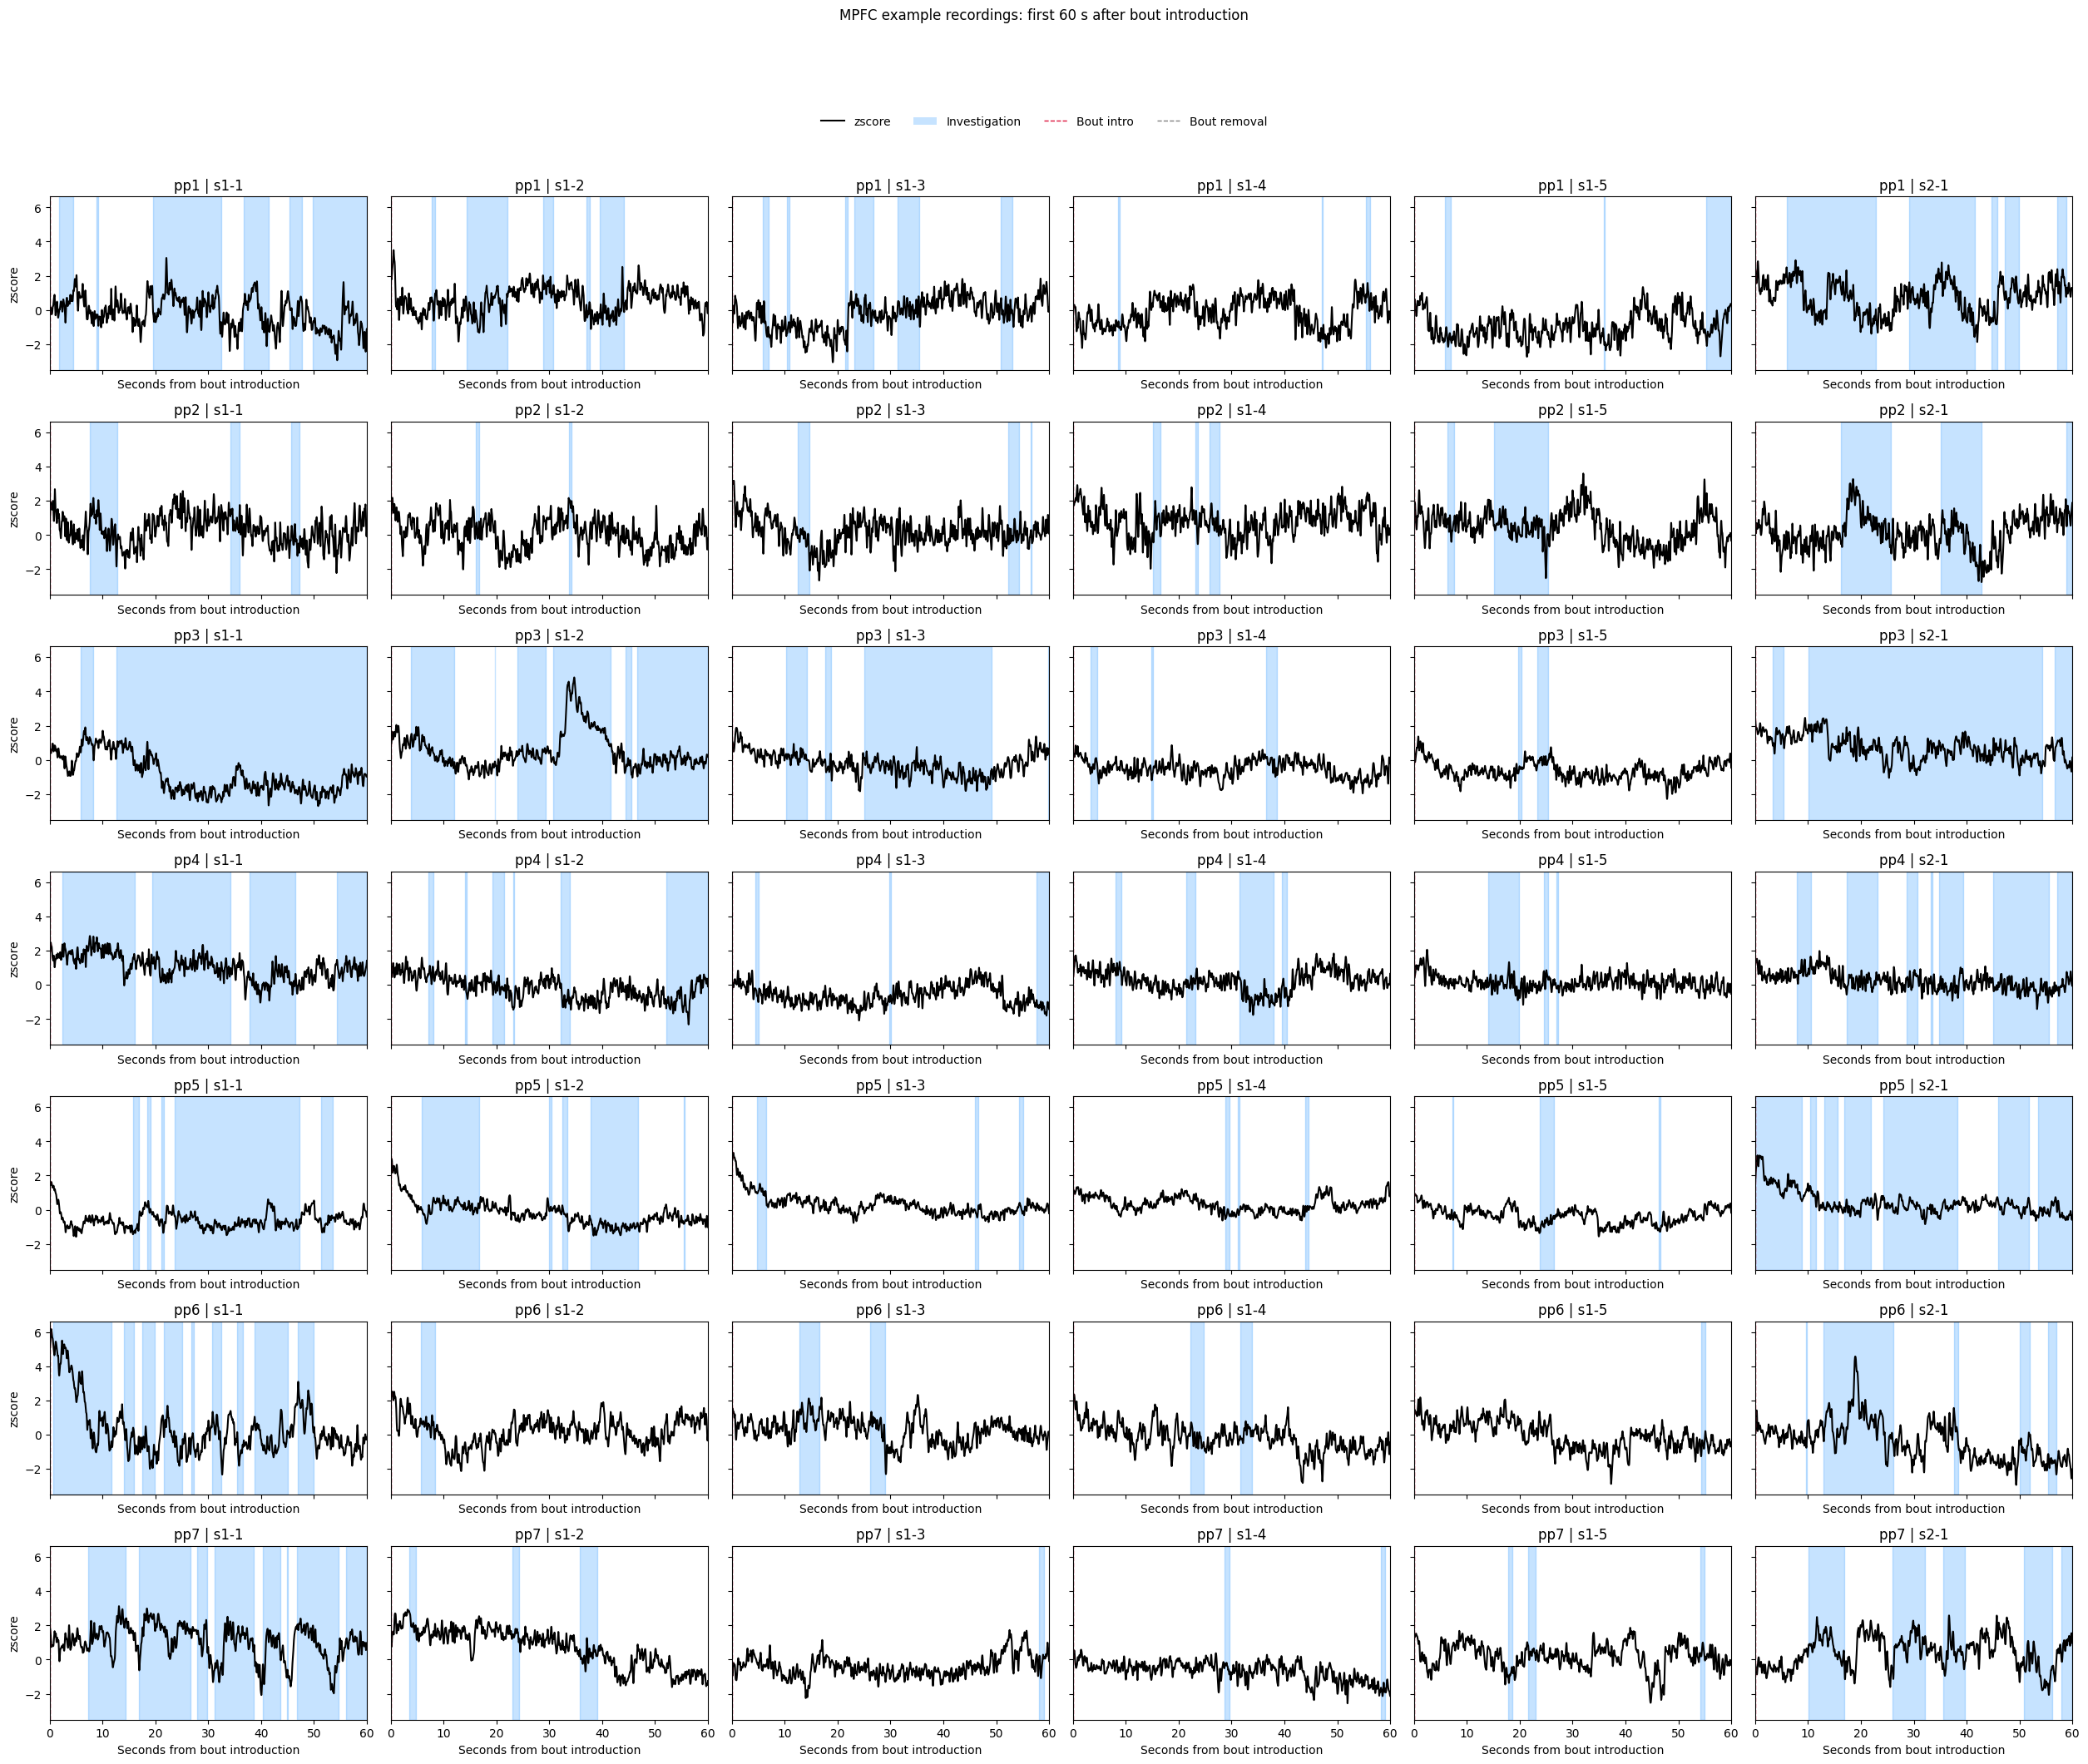

In [8]:
# Pick as many subjects as you want here.
subjects_to_plot = ['pp1','pp2','pp3','pp4', 'pp5', 'pp6','pp7']

plot_bout_intro_examples(
    experiment,
    subject_names=subjects_to_plot,
    bouts=BOUTS_TO_PLOT,
    window_s=60,
    behavior_name='Investigation',
    signal_name='zscore',
    sharey=True,
)

In [9]:
# Figure-ready export: no axes, no border, individual files, shared scale.
# Change `investigation_hex` to any hex color you want.

subjects_to_export = ['pp1']
bouts_to_export = ['s1-1', 's1-2','s1-3', 's1-4', 's1-5', 's2-1']
investigation_hex = '#1E90FF'
# investigation_hex = '#A6C6D3'



saved_paths, shared_y_limits = save_figure_ready_examples(
    experiment,
    subject_names=subjects_to_export,
    bouts=bouts_to_export,
    window_s=60,
    behavior_name='Investigation',
    signal_name='zscore',
    investigation_color=investigation_hex,
    output_dir=Path('figure_ready_examples') / REGION,
    file_prefix='hd_example',
    transparent=True,
    dpi=300,
)

print('Shared y-limits:', shared_y_limits)
for path in saved_paths:
    print(path)


Shared y-limits: (-3.3782198576523386, 3.8299564290304264)
figure_ready_examples\mpfc\hd_example_mpfc_pp1_s1-1_zscore.png
figure_ready_examples\mpfc\hd_example_mpfc_pp1_s1-2_zscore.png
figure_ready_examples\mpfc\hd_example_mpfc_pp1_s1-3_zscore.png
figure_ready_examples\mpfc\hd_example_mpfc_pp1_s1-4_zscore.png
figure_ready_examples\mpfc\hd_example_mpfc_pp1_s1-5_zscore.png
figure_ready_examples\mpfc\hd_example_mpfc_pp1_s2-1_zscore.png


### Notes

- Change `subjects_to_plot` to any set of subjects shown in `subject_table`.
- Change `BOUTS_TO_PLOT` if you only want a subset of bouts.
- If you want raw `dFF` instead of `zscore`, switch `signal_name='dFF'`.
- If you want one subject at a time, pass a single string like `subject_names='pp1'`.
- `save_figure_ready_examples(...)` exports one image per subject/bout with no axes, no ticks, and no visible border.
- Use `investigation_color='#HEXCODE'` to choose the overlay color.
- All exported files from one call share the same y-scale, which is returned as `shared_y_limits`.
- If you want a single example only, set one subject and one bout, for example `subjects_to_export = ['pp1']` and `bouts_to_export = ['s1-1']`.